# Masked Diffusion Language Model (MDLM) from Scratch

This notebook implements a **Masked Diffusion Language Model (MDLM)** from scratch in PyTorch.

Unlike GPT-style autoregressive models that generate text one token at a time left to right, MDLM starts with a fully masked sequence and iteratively denoises it in parallel, predicting all tokens simultaneously.

## Key Properties

- **Bidirectional context** - when predicting a masked token, the model attends to both left and right context
- **Parallel generation** - all tokens are refined simultaneously rather than sequentially
- **Native fill-in-the-middle** - infilling is a natural capability, not an architectural afterthought

## What We Implement

- Transformer architecture (bidirectional, no causal masking)
- MDLM noise schedule and training objective
- Fill-in-the-middle generation



## Stage 1: Setup
Install and import all required libraries. Run this notebook with a GPU - you can use the H100 runtime in Colab (Runtime → Change runtime type → H100).

In [ ]:
# Install dependencies
!pip install datasets tokenizers -q

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import ByteLevel
from tokenizers.decoders import ByteLevel as ByteLevelDecoder
import math
import random
import numpy as np
import matplotlib.pyplot as plt

# Set seeds for reproducibility
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Stage 2: Data
Load and tokenize WikiText-103, a standard English text dataset. We train a simple BPE tokenizer on the data and chunk it into fixed-length sequences for training.

In [ ]:
# Load WikiText
dataset = load_dataset("wikitext", "wikitext-103-raw-v1", trust_remote_code=True)
train_texts = [x["text"] for x in dataset["train"] if len(x["text"].strip()) > 0]
val_texts = [x["text"] for x in dataset["validation"] if len(x["text"].strip()) > 0]

# Train BPE tokenizer
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = ByteLevel()
trainer = BpeTrainer(vocab_size=16000, special_tokens=["[UNK]", "[MASK]", "[PAD]"])
tokenizer.train_from_iterator(train_texts, trainer=trainer)
tokenizer.decoder = ByteLevelDecoder()

MASK_ID = tokenizer.token_to_id("[MASK]")
PAD_ID = tokenizer.token_to_id("[PAD]")
VOCAB_SIZE = tokenizer.get_vocab_size()
print(f"Vocab size: {VOCAB_SIZE}")
print(f"MASK token id: {MASK_ID}")

# Chunk into fixed-length sequences
SEQ_LEN = 128

def chunk_texts(texts, seq_len):
    all_ids = []
    for text in texts:
        ids = tokenizer.encode(text).ids
        all_ids.extend(ids)
    chunks = []
    for i in range(0, len(all_ids) - seq_len, seq_len):
        chunks.append(all_ids[i:i+seq_len])
    return chunks

train_chunks = chunk_texts(train_texts, SEQ_LEN)
val_chunks = chunk_texts(val_texts, SEQ_LEN)
print(f"Train chunks: {len(train_chunks)}")
print(f"Val chunks: {len(val_chunks)}")

# Dataset class
class TextDataset(Dataset):
    def __init__(self, chunks):
        self.chunks = chunks

    def __len__(self):
        return len(self.chunks)

    def __getitem__(self, idx):
        return torch.tensor(self.chunks[idx], dtype=torch.long)

train_dataset = TextDataset(train_chunks)
val_dataset = TextDataset(val_chunks)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
print("Data ready.")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'wikitext' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'wikitext' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in a

README.md: 0.00B [00:00, ?B/s]

wikitext-103-raw-v1/test-00000-of-00001.(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-103-raw-v1/train-00000-of-00002(…):   0%|          | 0.00/157M [00:00<?, ?B/s]

wikitext-103-raw-v1/train-00001-of-00002(…):   0%|          | 0.00/157M [00:00<?, ?B/s]

wikitext-103-raw-v1/validation-00000-of-(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Vocab size: 16000
MASK token id: 1
Train chunks: 955420
Val chunks: 1997
Data ready.


## Stage 3: Model
We build a bidirectional Transformer from scratch with noise-level conditioning. Unlike GPT which uses causal (one-directional) attention, our transformer can attend to tokens on both the left and right. This is essential for MDLM because when predicting a masked token, the model needs to see the full surrounding context.

The transformer has four components:
- **Token + positional embedding** - converts token IDs into vectors, adds position information
- **Noise-level embedding** - sinusoidal embedding of t injected into every token position, telling the model how much of the sequence is masked
- **Transformer blocks** - stacked layers of self-attention + feedforward network
- **Output head** - projects back to vocabulary size to predict token probabilities

In [ ]:
VOCAB_SIZE = tokenizer.get_vocab_size()
D_MODEL = 512
N_HEADS = 8
N_LAYERS = 12
D_FF = 2048
DROPOUT = 0.1
SEQ_LEN = 128

class SinusoidalEmbedding(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.d_model = d_model

    def forward(self, t):
        device = t.device
        half = self.d_model // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=device) / half)
        args = t[:, None] * freqs[None]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_k = d_model // n_heads
        self.n_heads = n_heads
        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, T, C = x.shape
        q = self.q(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        k = self.k(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        v = self.v(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        attn = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_k)
        attn = F.softmax(attn, dim=-1)
        out = (attn @ v).transpose(1, 2).contiguous().view(B, T, C)
        return self.out(out)

class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, n_heads)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = x + self.drop(self.attn(self.norm1(x)))
        x = x + self.drop(self.ff(self.norm2(x)))
        return x

class MDLMTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, dropout, seq_len):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(seq_len, d_model)
        self.t_emb = SinusoidalEmbedding(d_model)
        self.t_proj = nn.Linear(d_model, d_model)
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, x, t):
        B, T = x.shape
        positions = torch.arange(T, device=x.device).unsqueeze(0)
        x = self.token_emb(x) + self.pos_emb(positions)
        t_emb = self.t_proj(self.t_emb(t))
        x = x + t_emb.unsqueeze(1)
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        return self.head(x)

model = MDLMTransformer(VOCAB_SIZE, D_MODEL, N_HEADS, N_LAYERS, D_FF, DROPOUT, SEQ_LEN).to(device)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Parameters: {count_parameters(model):,}")

Parameters: 54,557,824


## Stage 4: Training
The MDLM training loop. At each step we:
1. Sample a noise level t ~ Uniform(0, 1) for each sequence
2. Randomly mask tokens with probability t
3. Feed the masked sequence and t into the transformer
4. Compute cross entropy loss only at the masked positions, weighted by 1/t
5. Backpropagate and update weights

The 1/t weighting follows the MDLM paper (Sahoo et al. 2024) - low noise levels (few masks) are upweighted because precise reconstruction from rich context matters more than reconstruction from near-total noise.

Epoch 1/20 | train loss: 14.6287 | val loss: 14.0751
Epoch 2/20 | train loss: 13.9132 | val loss: 13.1834
Epoch 3/20 | train loss: 12.9433 | val loss: 12.4575
Epoch 4/20 | train loss: 12.2558 | val loss: 12.0906
Epoch 5/20 | train loss: 11.7560 | val loss: 11.2865
Epoch 6/20 | train loss: 11.4044 | val loss: 11.1321
Epoch 7/20 | train loss: 11.1249 | val loss: 10.8641
Epoch 8/20 | train loss: 10.8984 | val loss: 10.5598
Epoch 9/20 | train loss: 10.6954 | val loss: 10.5453
Epoch 10/20 | train loss: 10.5186 | val loss: 10.4074
Epoch 11/20 | train loss: 10.3555 | val loss: 10.2293
Epoch 12/20 | train loss: 10.2069 | val loss: 9.9243
Epoch 13/20 | train loss: 10.0719 | val loss: 9.8571
Epoch 14/20 | train loss: 9.9505 | val loss: 9.6380
Epoch 15/20 | train loss: 9.8301 | val loss: 9.6021
Epoch 16/20 | train loss: 9.7232 | val loss: 9.5378
Epoch 17/20 | train loss: 9.6308 | val loss: 9.3661
Epoch 18/20 | train loss: 9.5425 | val loss: 9.3158
Epoch 19/20 | train loss: 9.4691 | val loss: 9.19

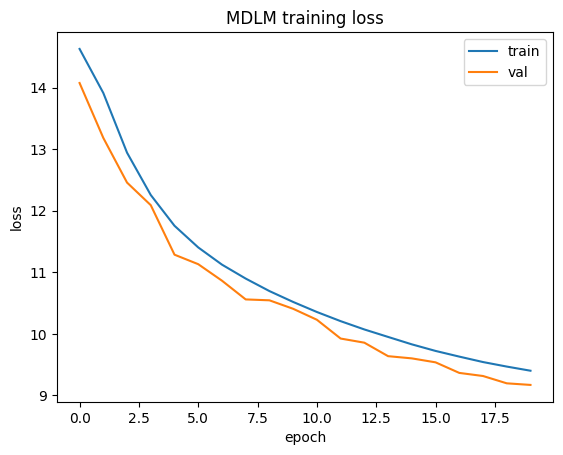

In [ ]:
def mask_tokens(batch, mask_id, vocab_size):
    B, T = batch.shape
    t = torch.rand(B, device=batch.device)
    t_expanded = t.unsqueeze(1).expand(B, T)
    mask = torch.rand(B, T, device=batch.device) < t_expanded
    noisy = batch.clone()
    noisy[mask] = mask_id
    return noisy, mask, t

def train_epoch(model, loader, optimizer, mask_id, vocab_size):
    model.train()
    total_loss = 0
    total_tokens = 0

    for batch in loader:
        batch = batch.to(device)
        noisy, mask, t = mask_tokens(batch, mask_id, vocab_size)

        logits = model(noisy, t)
        logits_masked = logits[mask]
        targets_masked = batch[mask]

        mask_indices = mask.nonzero(as_tuple=True)[0]
        per_token_loss = F.cross_entropy(logits_masked, targets_masked, reduction='none')
        t_weights = 1.0 / t.clamp(min=0.01)
        loss = (per_token_loss * t_weights[mask_indices]).mean()

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * mask.sum().item()
        total_tokens += mask.sum().item()

    return total_loss / total_tokens

def val_epoch(model, loader, mask_id, vocab_size):
    model.eval()
    total_loss = 0
    total_tokens = 0

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            noisy, mask, t = mask_tokens(batch, mask_id, vocab_size)
            logits = model(noisy, t)
            logits_masked = logits[mask]
            targets_masked = batch[mask]

            mask_indices = mask.nonzero(as_tuple=True)[0]
            per_token_loss = F.cross_entropy(logits_masked, targets_masked, reduction='none')
            t_weights = 1.0 / t.clamp(min=0.01)
            loss = (per_token_loss * t_weights[mask_indices]).mean()

            total_loss += loss.item() * mask.sum().item()
            total_tokens += mask.sum().item()

    return total_loss / total_tokens

EPOCHS = 20
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.1)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=3e-4,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS
)

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, MASK_ID, VOCAB_SIZE)
    val_loss = val_epoch(model, val_loader, MASK_ID, VOCAB_SIZE)
    scheduler.step()
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} | train loss: {train_loss:.4f} | val loss: {val_loss:.4f}")

plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("MDLM training loss")
plt.show()

## Stage 5: Fill-in-the-Middle
The key advantage of MDLM over autoregressive models - infilling is native.

We give the model a prefix and suffix, mask the middle, and let it fill in the gap. An autoregressive model like GPT cannot do this without tricks. MDLM does it naturally because it attends to both left and right context simultaneously.

In [ ]:
def fill_in_the_middle(model, tokenizer, mask_id, prefix, suffix, middle_len=20, steps=50, temperature=1.0):
    model.eval()
    prefix_ids = tokenizer.encode(prefix).ids
    suffix_ids = tokenizer.encode(suffix).ids
    middle_masks = [mask_id] * middle_len
    full_ids = (prefix_ids + middle_masks + suffix_ids)[:SEQ_LEN]
    x = torch.tensor(full_ids, dtype=torch.long, device=device).unsqueeze(0)
    prefix_len = len(prefix_ids)
    middle_positions = list(range(prefix_len, prefix_len + middle_len))
    masks_per_step = max(1, middle_len // steps)

    with torch.no_grad():
        for step in range(steps):
            t_val = (x[0] == mask_id).float().mean().unsqueeze(0)
            logits = model(x, t_val)
            probs = F.softmax(logits / temperature, dim=-1)
            sampled = torch.multinomial(probs[0], num_samples=1).squeeze(-1)
            still_masked = [p for p in middle_positions if x[0, p].item() == mask_id]
            if not still_masked:
                break
            still_masked_t = torch.tensor(still_masked, device=device)
            confidence = probs[0, still_masked_t].max(dim=-1).values
            n_unmask = min(masks_per_step, len(still_masked))
            top_indices = confidence.topk(n_unmask).indices
            positions_to_unmask = still_masked_t[top_indices]
            x[0, positions_to_unmask] = sampled[positions_to_unmask]

    prefix_decoded = tokenizer.decode(x[0, :prefix_len].tolist())
    middle_decoded = tokenizer.decode(x[0, prefix_len:prefix_len+middle_len].tolist())
    suffix_decoded = tokenizer.decode(x[0, prefix_len+middle_len:].tolist())
    return prefix_decoded, middle_decoded, suffix_decoded

examples = [
    ("The battle was fought in the mountains", "resulting in a decisive victory.", 8),
    ("The species is native to", "and was first described by scientists.", 8),
    ("He was born in New York and", "before retiring from public life.", 10),
    ("The river flows through", "before emptying into the ocean.", 8),
    ("The film was a critical success and", "by audiences worldwide.", 8),
]

print("=== Fill-in-the-Middle Demo ===\n")
for prefix, suffix, mid_len in examples:
    pre, mid, suf = fill_in_the_middle(model, tokenizer, MASK_ID, prefix, suffix, middle_len=mid_len)
    print(f"Prefix:  {pre}")
    print(f"Middle:  [{mid}]")
    print(f"Suffix:  {suf}")
    print()

=== Fill-in-the-Middle Demo ===

Prefix:   The battle was fought in the mountains
Middle:  [ , as well asing fire , and]
Suffix:   resulting in a decisive victory.

Prefix:   The species is native to
Middle:  [ resemble the Flora Quuesham type]
Suffix:   and was first described by scientists.

Prefix:   He was born in New York and
Middle:  [ Indiana in 1945 during his last six years and not]
Suffix:   before retiring from public life.

Prefix:   The river flows through
Middle:  [ the Rocky Young . The hills branchesatra]
Suffix:   before emptying into the ocean.

Prefix:   The film was a critical success and
Middle:  [ result of holds worldwide @-@ distribution , isolated]
Suffix:   by audiences worldwide.

